# Árvores II - Tarefa 2

### 1. Carregar as bases

Vamos carregar as bases lidas na tarefa passada. Se você salvou essas bases em arquivo texto, basta fazer a leitura com o comando ```pd.read_csv``` das seguintes bases:

- X_train
- Y_train
- X_test
- Y_test

Não se esqueça de considerar a leitura dos índices dos arquivos no ```read_csv()```!

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import plot_confusion_matrix

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay

X_train = pd.read_csv('X_train.csv', index_col=[0,1])
y_train = pd.read_csv('y_train.csv')['activity']
X_test  = pd.read_csv('X_test.csv', index_col=[0,1])
y_test  = pd.read_csv('y_test.csv')['activity']

print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(7352, 561) (2947, 561)
(7352,) (2947,)


### 2. Divisão da base em Treino, Validação e Teste

A base já se encontra dividida em Treino e Validação. O que vamos fazer então é extrair uma base de Validação da base de Treino.

Extraia 25% da base de treino como base de validação.

item 2

In [2]:
X_treino, X_val, y_treino, y_val = train_test_split(
    X_train, y_train, test_size=0.25, random_state=100, stratify=y_train
)
print(X_treino.shape, X_val.shape)

(5514, 561) (1838, 561)


### 3. Melhores 3 variáveis

Rode uma árvore com profundidade máxima igual a 4 para prever a atividade humana com todas as variáveis.
Observe a importância das variáveis e considere as 3 variáveis com maior importância para os próximos passos.
Dica: utilize o atributo ```clf.feature_importances_``` da árvore treinada.

In [3]:
arvore4 = DecisionTreeClassifier(max_depth=4, random_state=100)
arvore4.fit(X_treino, y_treino)

importancias = pd.Series(arvore4.feature_importances_, index=X_treino.columns)
top3 = importancias.sort_values(ascending=False).head(3)
print(top3)
melhores_3 = top3.index.tolist()

tGravityAcc-mean()-X              0.282909
fBodyAccJerk-bandsEnergy()-1,8    0.254259
tGravityAcc-max()-Y               0.165666
dtype: float64


### 4. Construa uma árvore com as 3 melhores variáveis

Utilizando as três variáveis encontradas acima, construa uma árvore de decisão. Encontre o melhor ```ccp_alpha``` utilizando a base de validação, conforme a estrutura que vimos em aula.

In [4]:
%%time

%%time
X_treino_3 = X_treino[melhores_3]
X_val_3 = X_val[melhores_3]
X_test_3 = X_test[melhores_3]

arvore_inicial = DecisionTreeClassifier(min_samples_leaf=20, random_state=100)
arvore_inicial.fit(X_treino_3, y_treino)

path = arvore_inicial.cost_complexity_pruning_path(X_treino_3, y_treino)
ccp_alphas = np.unique(path.ccp_alphas[path.ccp_alphas >= 0])[::5]

modelos, acc_treino, acc_val = [], [], []

for alpha in ccp_alphas:
    clf = DecisionTreeClassifier(
        min_samples_leaf=20, random_state=100, ccp_alpha=alpha
    )
    clf.fit(X_treino_3, y_treino)
    modelos.append(clf)
    acc_treino.append(clf.score(X_treino_3, y_treino))
    acc_val.append(clf.score(X_val_3, y_val))

melhor_i = np.argmax(acc_val)
melhor_modelo = modelos[melhor_i]
print("Melhor alpha:", ccp_alphas[melhor_i])
print("Acurácia validação:", acc_val[melhor_i])

Melhor alpha: 0.0012224285891315268
Acurácia validação: 0.8596300326441785
CPU times: total: 672 ms
Wall time: 674 ms
CPU times: total: 672 ms
Wall time: 675 ms


### 5. Avaliação do modelo

Avalie a árvore encontrada no item anterior na base de testes.

Acurácia no teste: 0.7393959959280625


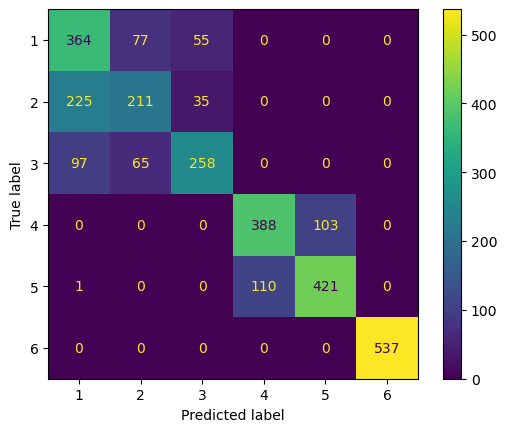

In [5]:
acc_teste = melhor_modelo.score(X_test_3, y_test)
print("Acurácia no teste:", acc_teste)

ConfusionMatrixDisplay.from_estimator(melhor_modelo, X_test_3, y_test)
plt.show()